# load_diabetes

In [1]:
#загрузка библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

In [2]:
#загрузка датасета
from sklearn.datasets import load_diabetes
diabetes_sk = load_diabetes()

In [3]:
diabetes_sk.data

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [4]:
diabetes_sk.data.shape
#442 наблюдения, 10 переменных

(442, 10)

In [5]:
features = diabetes_sk.feature_names
features

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

The Sklearn Diabetes Dataset include following attributes:

*   age: Age in years
*   sex: Gender of the patient
*   bmi: Body mass index
*   bp: Average blood pressure
*   s1: Total serum cholesterol (tc)
*   s2: Low-density lipoproteins (ldl)
*   s3: High-density lipoproteins (hdl)
*   s4: Total cholesterol / HDL (tch)
*   s5: Possibly log of serum triglycerides level (ltg)
*   s6: Blood sugar level (glu)

In [6]:
#преобразование датасета в dataframe pd
diabetes_df = pd.DataFrame(data=diabetes_sk.data, columns=diabetes_sk.feature_names)
diabetes_df['target'] = diabetes_sk.target

In [7]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
diabetes_df.shape
#442 наблюдения, 10 независимых переменных, 1 целевая переменная

(442, 11)

In [9]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [10]:
#вывод основной статистики
diabetes_df.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


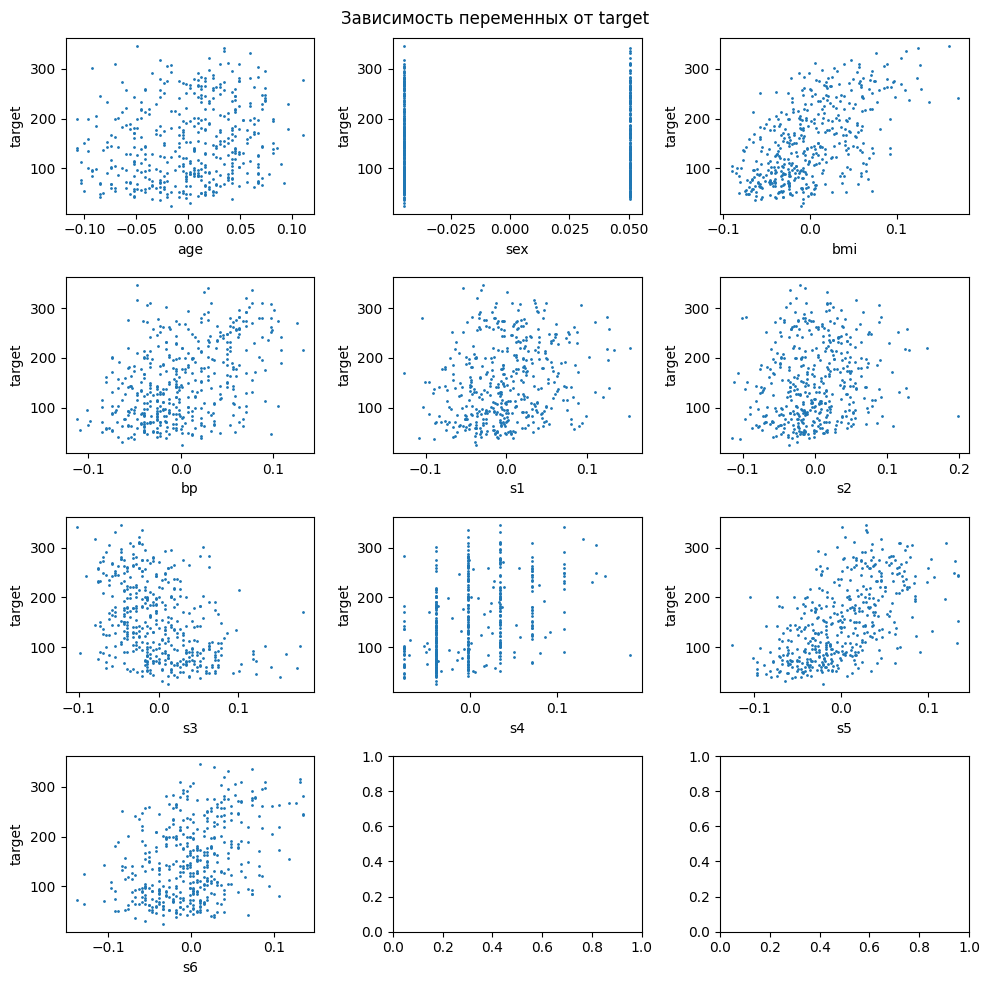

In [11]:
#зависимость переменных от таргета
fig, axs = plt.subplots(4, 3, figsize=(10, 10))
fig.suptitle('Зависимость переменных от target')
for i, column in enumerate(features):
    row = i // 3  # вычисляем строку
    col = i % 3   # вычисляем столбец
    n = col + row * 3
    feature = features[n]
    axs[row, col].scatter(diabetes_df.iloc[:,n], diabetes_df.target, s=1)
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel('target')
plt.tight_layout()
plt.show()

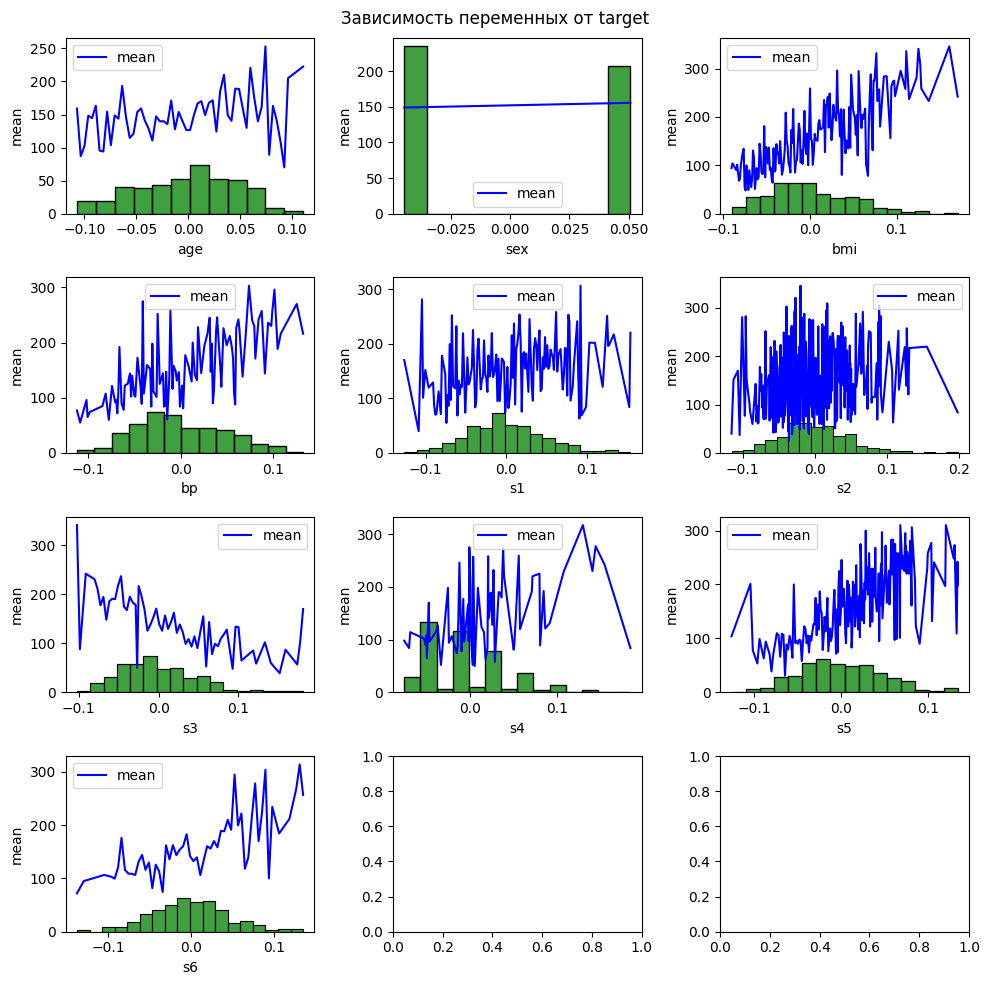

In [12]:
#зависимость переменных от таргета
fig, axs = plt.subplots(4, 3, figsize=(10, 10))
fig.suptitle('Зависимость переменных от target')
for i, column in enumerate(features):
    row = i // 3  # вычисляем строку
    col = i % 3   # вычисляем столбец
    piv=diabetes_df.pivot_table(index=column,values='target',aggfunc={'target': ['count', 'mean']},dropna=False)
    piv.sort_values('mean', ascending=True, inplace=True)
    piv.insert(1,'percent',piv['count']/len(diabetes_df)*100)
    sns.lineplot(data=piv,x=column,y="mean",color='blue',label='mean',ax=axs[row, col])
    sns.histplot(data=diabetes_df,x=column,color='green',label='count',ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

In [13]:
#корреляционная матрица
correlation_matrix = diabetes_df.corr()
correlation_matrix

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


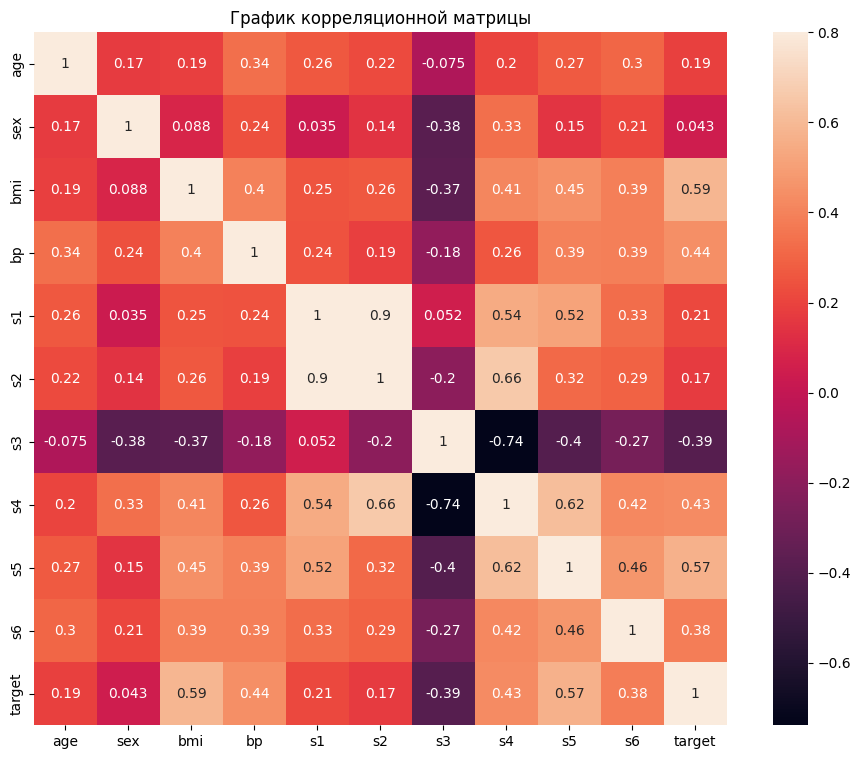

In [14]:
#график корреляционной матрицы
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, vmax = .8, square = True)
plt.title('График корреляционной матрицы')
plt.show()

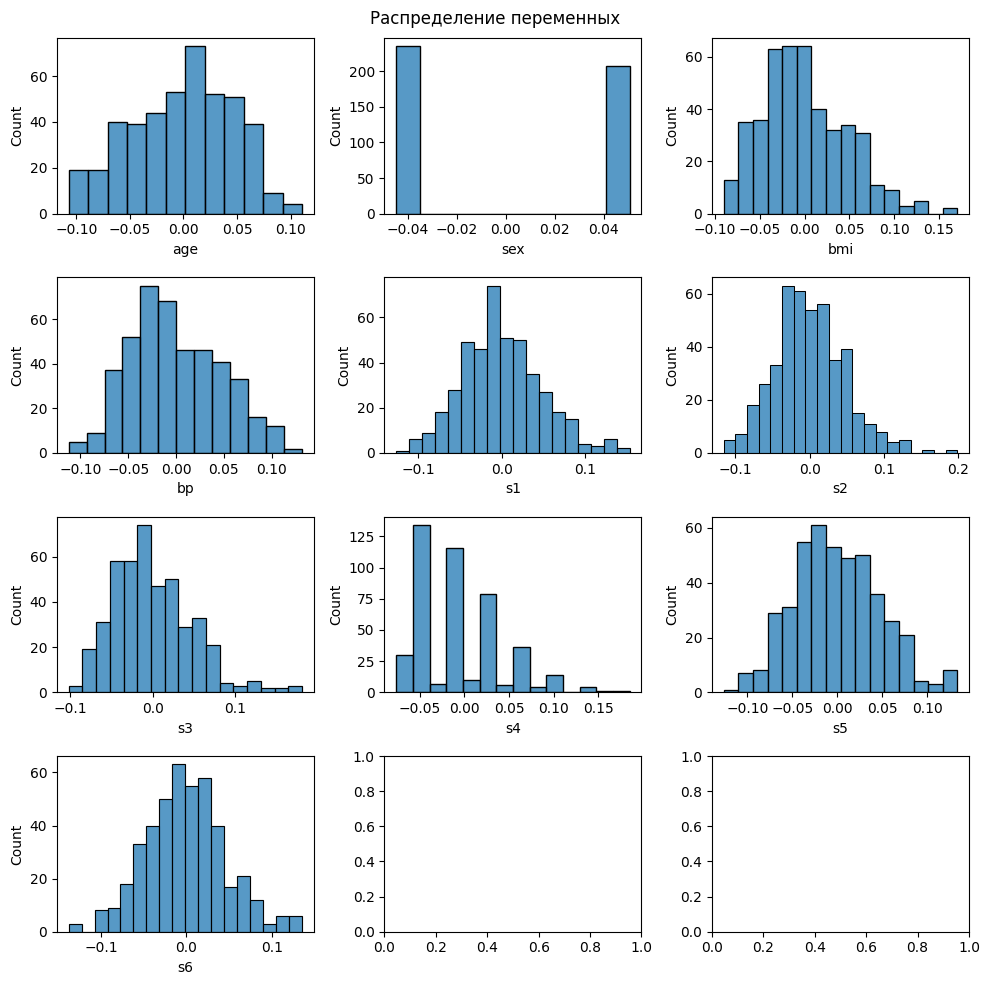

In [15]:
#график распределения переменных
fig, axs = plt.subplots(4, 3, figsize=(10, 10))
fig.suptitle('Распределение переменных')
for i, column in enumerate(features):
    row = i // 3  # вычисляем строку
    col = i % 3   # вычисляем столбец
    sns.histplot(x=column, data=diabetes_df, ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

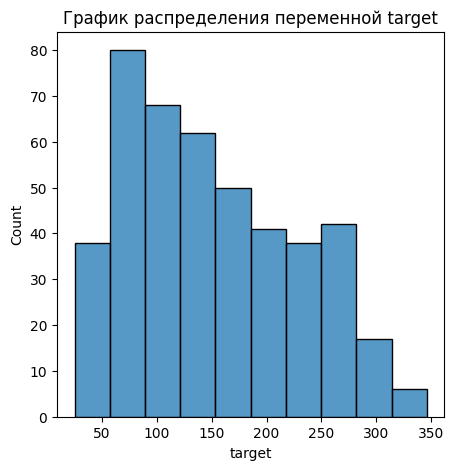

In [16]:
#график распределения переменной target
plt.figure(figsize=(5, 5))
sns.histplot(diabetes_df.target)
plt.title('График распределения переменной target')
plt.show()

In [17]:
#анализ нулевых значений, отсутствуют
diabetes_df_null=diabetes_df.isnull().sum()
diabetes_df_null

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [18]:
y = diabetes_df.target
X = diabetes_df.drop(['target'], axis=1)

In [19]:
#независимые переменные
X.shape

(442, 10)

In [20]:
#целевая переменная
y.shape

(442,)

In [21]:
from sklearn.model_selection import train_test_split

#разбиваем датасет на обучающий и проверочный
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)
print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("y_train", y_train.shape)
print("y_val", y_val.shape)

X_train (353, 10)
X_val (89, 10)
y_train (353,)
y_val (89,)


In [22]:
from sklearn.linear_model import LinearRegression

#строим модель
reg = LinearRegression()
reg.fit(X, y)

LinearRegression()

In [24]:
#параметры модели
slope = reg.coef_
print('slope:', slope)

slope: [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]


In [25]:
#параметры модели
intercept = reg.intercept_
print('intercept:', intercept)

intercept: 152.13348416289597


In [26]:
r_sq = reg.score(X, y)
print('Коэффициент детерминации', r_sq)

Коэффициент детерминации 0.5177484222203499


In [27]:
#расчет целевой переменной на тестовой выборке
y_pred = reg.predict(X_val)
y_pred

array([120.66560385, 112.11054883, 179.15576252,  69.47575778,
       174.82799914, 193.01756549, 220.67516721, 121.22668124,
       159.93677518, 128.46225834, 211.85894518, 202.39971737,
        91.20395862,  75.16804478, 235.16173729, 203.8691938 ,
       180.13082199, 100.70810916, 115.86820464, 171.80344337,
       190.14568824,  84.17319946, 142.20991224, 106.35191443,
        92.68731024, 212.28734795,  92.86459928, 174.89158814,
       122.05921633, 182.84134823, 160.41761959, 138.35467112,
       191.33777472,  99.73771331, 166.82164929, 191.90710484,
       109.49562511, 245.15862773, 172.55288732, 189.95771575,
       164.48838425, 184.7811403 , 122.53559675, 123.83461591,
       146.99841953, 204.05976093, 150.64748328, 141.82052358,
       190.33892524, 191.89092557,  61.12935368, 155.67052006,
       106.92902558, 151.2469168 , 189.19505093, 124.34152283,
       162.64748776,  81.79874055,  53.47338214,  79.93968011,
       104.57681546, 199.28001608, 169.59494046, 110.07

In [28]:
#метрики для оценки модели
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
print('mean_squared_error', mse)
print('mean_absolute_error', mae)

mean_squared_error 2931.7932500939487
mean_absolute_error 42.08821063688747


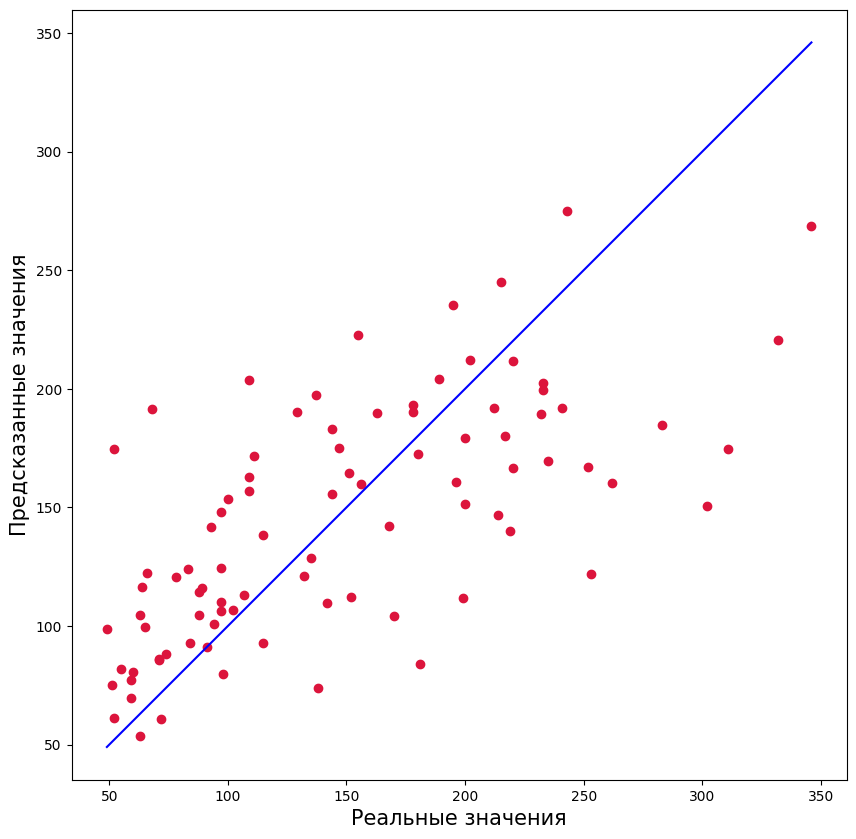

In [29]:
plt.figure(figsize=(10,10))
plt.scatter(y_val, y_pred, c='crimson')
p1 = max(max(y_pred), max(y_val))
p2 = min(min(y_pred), min(y_val))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('Реальные значения', fontsize=15)
plt.ylabel('Предсказанные значения', fontsize=15)
plt.axis('equal')
plt.show()

# load_iris

In [30]:
#загрузка датасета
from sklearn.datasets import load_iris
iris_sk = load_iris()

In [31]:
iris_sk.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [32]:
iris_sk.data.shape
#150 наблюдений, 4 переменных

(150, 4)

In [33]:
features_iris = iris_sk.feature_names
features_iris

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [34]:
#преобразование датасета в dataframe pd
iris_df = pd.DataFrame(data=iris_sk.data, columns=iris_sk.feature_names)
iris_df['target'] = iris_sk.target

In [35]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [36]:
iris_df.shape
#150 наблюдений, 4 независимых переменных, 1 целевая переменная

(150, 5)

In [37]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [38]:
#вывод основной статистики
iris_df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


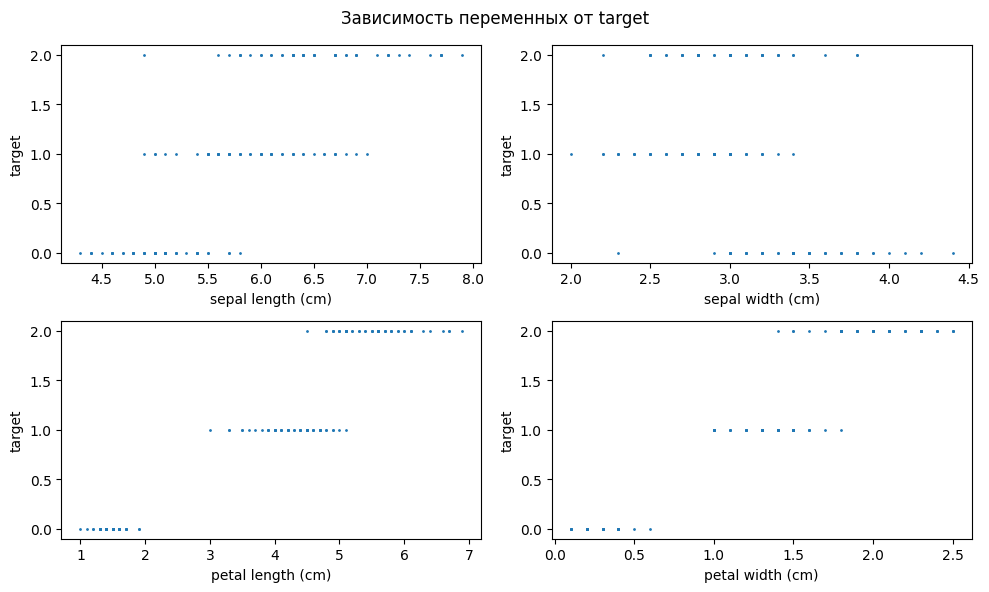

In [39]:
#зависимость переменных от таргета
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Зависимость переменных от target')
for i, column in enumerate(features_iris):
    row = i // 2  # вычисляем строку
    col = i % 2   # вычисляем столбец
    n = col + row * 2
    feature = features_iris[n]
    axs[row, col].scatter(iris_df.iloc[:,n], iris_df.target, s=1)
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel('target')
plt.tight_layout()
plt.show()

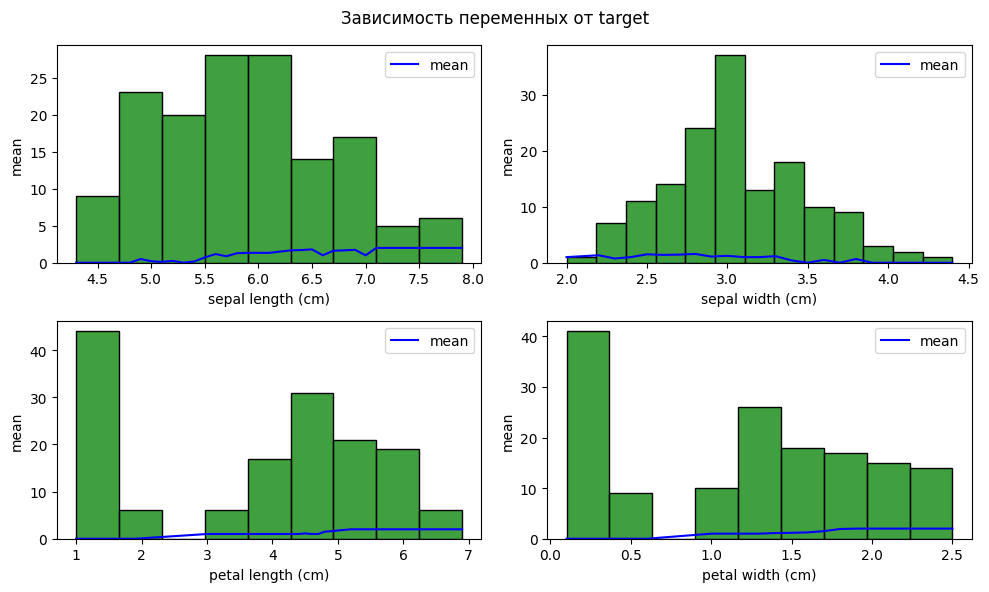

In [40]:
#зависимость переменных от таргета
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Зависимость переменных от target')
for i, column in enumerate(features_iris):
    row = i // 2  # вычисляем строку
    col = i % 2   # вычисляем столбец
    piv=iris_df.pivot_table(index=column,values='target',aggfunc={'target': ['count', 'mean']},dropna=False)
    piv.sort_values('mean', ascending=True, inplace=True)
    piv.insert(1,'percent',piv['count']/len(iris_df)*100)
    sns.lineplot(data=piv,x=column,y="mean",color='blue',label='mean',ax=axs[row, col])
    sns.histplot(data=iris_df,x=column,color='green',label='count',ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

In [41]:
#корреляционная матрица
correlation_matrix = iris_df.corr()
correlation_matrix

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


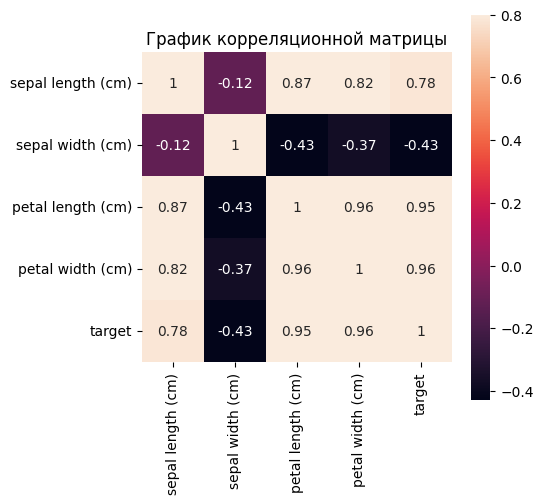

In [42]:
#график корреляционной матрицы
plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, vmax = .8, square = True)
plt.title('График корреляционной матрицы')
plt.show()

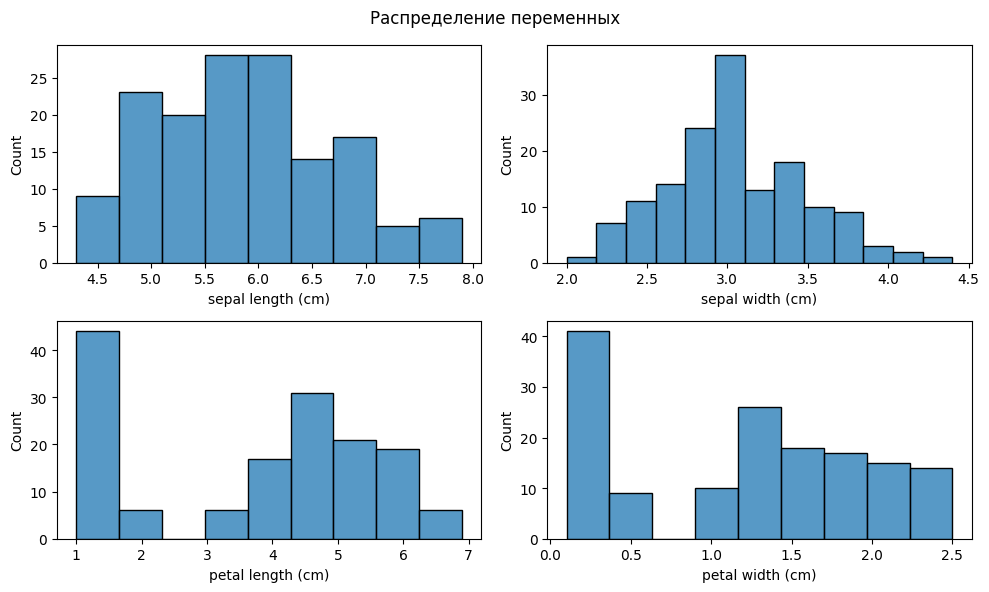

In [43]:
#график распределения переменных
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Распределение переменных')
for i, column in enumerate(features_iris):
    row = i // 2  # вычисляем строку
    col = i % 2   # вычисляем столбец
    sns.histplot(x=column, data=iris_df, ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

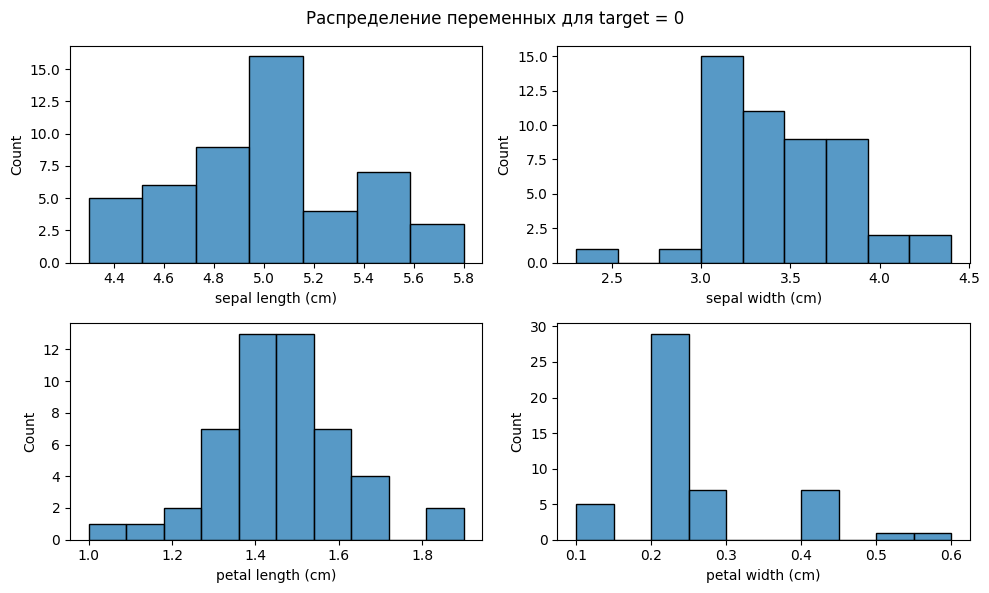

In [53]:
#график распределения переменных
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Распределение переменных для target = 0')
for i, column in enumerate(features_iris):
    row = i // 2  # вычисляем строку
    col = i % 2   # вычисляем столбец
    sns.histplot(x=column, data=iris_df[iris_df['target'] == 0], ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

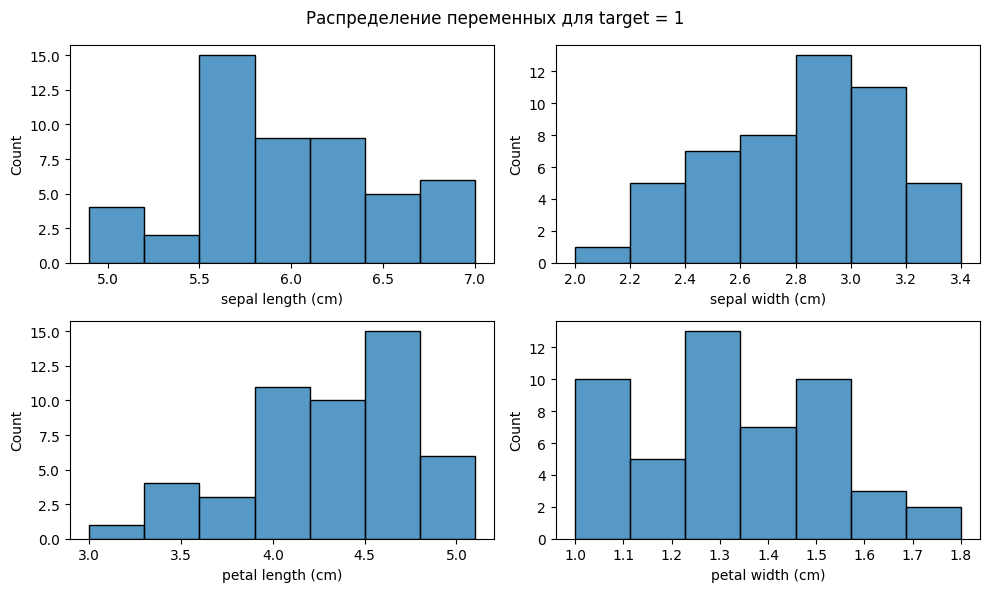

In [54]:
#график распределения переменных
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Распределение переменных для target = 1')
for i, column in enumerate(features_iris):
    row = i // 2  # вычисляем строку
    col = i % 2   # вычисляем столбец
    sns.histplot(x=column, data=iris_df[iris_df['target'] == 1], ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

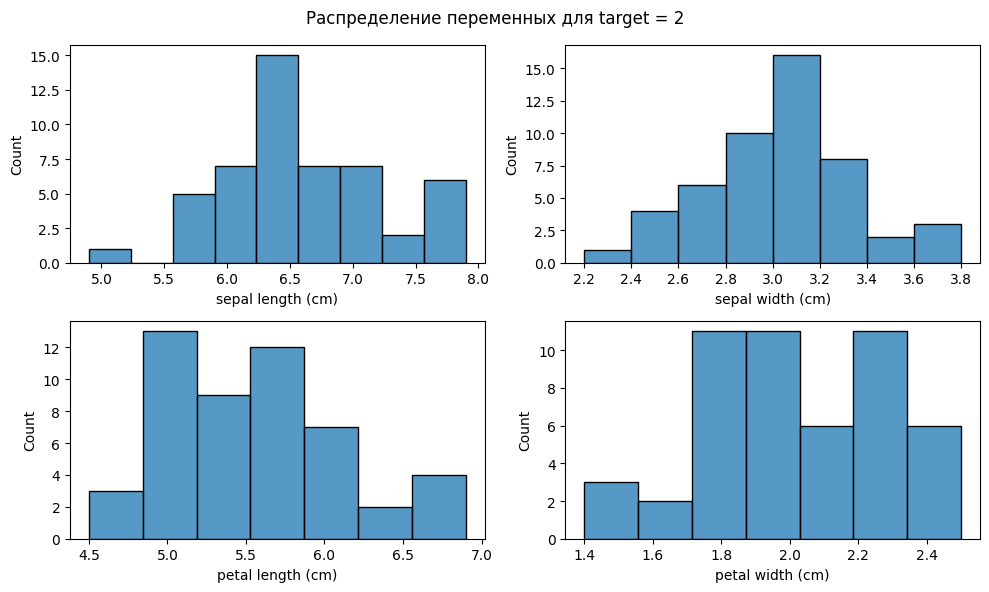

In [55]:
#график распределения переменных
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Распределение переменных для target = 2')
for i, column in enumerate(features_iris):
    row = i // 2  # вычисляем строку
    col = i % 2   # вычисляем столбец
    sns.histplot(x=column, data=iris_df[iris_df['target'] == 2], ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

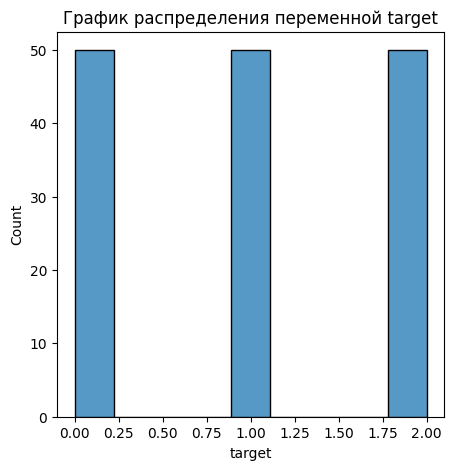

In [56]:
#график распределения переменной target
plt.figure(figsize=(5, 5))
sns.histplot(iris_df.target)
plt.title('График распределения переменной target')
plt.show()

In [57]:
#анализ нулевых значений, отсутствуют
iris_df_null=iris_df.isnull().sum()
iris_df_null

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [58]:
y = iris_df.target
X = iris_df.drop(['target'], axis=1)

In [59]:
#независимые переменные
X.shape

(150, 4)

In [60]:
#целевая переменная
y.shape

(150,)

In [61]:
from sklearn.model_selection import train_test_split

#разбиваем датасет на обучающий и проверочный
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)
print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("y_train", y_train.shape)
print("y_val", y_val.shape)

X_train (120, 4)
X_val (30, 4)
y_train (120,)
y_val (30,)


In [62]:
from sklearn.linear_model import LogisticRegression

#строим модель
#logreg = LogisticRegression(C=10, penalty='l1', solver='saga', multi_class='multinomial',max_iter=10000)
logreg = LogisticRegression(C=10, penalty='l1', solver='saga', multi_class='multinomial',max_iter=10000)
logreg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10, max_iter=10000, multi_class='multinomial',
                   penalty='l1', solver='saga')

In [63]:
r_sq = logreg.score(X, y)
print('Коэффициент детерминации', r_sq)

Коэффициент детерминации 0.98


In [64]:
#расчет целевой переменной на тестовой выборке
y_pred = logreg.predict(X_val)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 2, 1, 0, 0, 1, 2])

In [65]:
#расчет целевой переменной на тестовой выборке (принадлежность классу)
y_pred_proba = logreg.predict_proba(X_val)
y_pred_proba

array([[9.99991756e-01, 8.24386692e-06, 7.25261018e-20],
       [4.53832678e-02, 9.54585119e-01, 3.16130401e-05],
       [1.58344595e-03, 9.95311502e-01, 3.10505178e-03],
       [9.99975527e-01, 2.44734420e-05, 5.93079891e-18],
       [1.74511968e-07, 2.03375140e-02, 9.79662312e-01],
       [9.12157086e-04, 9.39146460e-01, 5.99413828e-02],
       [5.30978894e-06, 2.09876232e-02, 9.79007067e-01],
       [9.98876564e-01, 1.12343577e-03, 1.62865227e-14],
       [9.95435726e-01, 4.56427392e-03, 4.00043529e-14],
       [2.08319948e-08, 1.27650177e-03, 9.98723477e-01],
       [4.26675685e-04, 9.86638352e-01, 1.29349720e-02],
       [9.99803738e-01, 1.96261868e-04, 3.73389955e-16],
       [5.32217266e-09, 2.04229550e-03, 9.97957699e-01],
       [1.82678970e-03, 9.87552415e-01, 1.06207950e-02],
       [3.59276044e-04, 9.39379309e-01, 6.02614147e-02],
       [9.98673494e-01, 1.32650600e-03, 5.14044746e-15],
       [9.14700977e-04, 9.97357542e-01, 1.72775685e-03],
       [3.22666288e-04, 8.85182

In [66]:
#метрики для оценки модели
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
print('mean_squared_error', mse)
print('mean_absolute_error', mae)

mean_squared_error 0.0
mean_absolute_error 0.0
